In [1]:
### IMPORTS ###
import sys
sys.path.append('../')

import autolib
import fom
import Optimisation.opt as opt
import pathlib
#from pathlib import PosixPath
#user_home_path = PosixPath('~/')
#user_home_path_full = user_home_path.expanduser()


final_speed = 20.
num_cores = 200
maxtime = 1440
runID = "Fasympmonochrome_fixgaussian20_50GW_nG30"
#runID = "Fasymp20_fixgaussian20_50GW" # _nG30"

student = "JadonsSolution"  # Change this to your name or preferred folder name

# common_path = user_home_path_full / "Library/CloudStorage/OneDrive-TheUniversityofSydney(Students)/Doppler Damping - Jadon Lin/Documentation/Data/relativistic-lightsail-dynamics/Optimisation/Jadon's results"
# custom_folder_path = f"Fasymp/final_speed{int(final_speed)}/maxtime{int(maxtime)}/{runID}"
# custom_folder_path = f"Fasymp/mono/maxtime{int(maxtime)}/{runID}"

filepath = "Z:\\Github\\relativistic-lightsail-dynamics\\Optimisation\\run_parallel_extract.ipynb"
filepath = "combine_extract.ipynb"
current_dir = pathlib.Path(filepath).resolve(strict=True).parent
fname_preamble = current_dir / "Data" / student

# fname_preamble = common_path / custom_folder_path

# import pathlib
# fname_preamble = pathlib.Path("./Data")

pkl_fname = fname_preamble / f'{runID}_FOM_optimisation_maxtime{maxtime}'
txt_fname = fname_preamble / f'{runID}_FOM_optimisation_maxtime{maxtime}_curated.txt'

maxima_and_maximisers_sorted, opt_gratings_sorted, _ = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=0)

Total function evaluations: 7171191
Average function evaluations per core: 35855


In [2]:
def print_grating_params(grating):
    print(f"grating_pitch   = {grating.params[0]}")
    print(f"grating_depth   = {grating.params[1]}")
    print(f"box1_width      = {grating.params[2]}")
    print(f"box2_width      = {grating.params[3]}")
    print(f"box_centre_dist = {grating.params[4]}")
    print(f"box1_eps        = {grating.params[5]}")
    print(f"box2_eps        = {grating.params[6]}")
    print(f"gaussian_width  = {grating.params[7]}")
    print(f"substrate_depth = {grating.params[8]}")
    print(f"substrate_eps   = {grating.params[9]}")

In [3]:
import numpy as np
import os
os.environ["OMP_NUM_THREADS"] = "1" 
os.environ["OPENBLAS_NUM_THREADS"] = "1" 
os.environ["MKL_NUM_THREADS"] = "1" 
os.environ["VECLIB_MAXIMUM_THREADS"] = "1" 
os.environ["NUMEXPR_NUM_THREADS"] = "1" 

import parameters
from parameters import D1_ND

from twobox import TwoBox

I0, L, m, c = parameters.Parameters()
optimum_number = 4

# wavelength_range = [1,1/D1_ND([final_speed/100,0])]
wavelength_range = [0.99999,1.0000004]
bandwidth = wavelength_range[1] - wavelength_range[0]
relative_bandwidth = bandwidth / wavelength_range[0]
wavelength_range = [0.99999 - 10.*relative_bandwidth, 1.0000004 + 10.*relative_bandwidth]
print(wavelength_range)
_, _, opt_grating = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=optimum_number)
optimisation_RCWA_engine = opt_grating.RCWA_engine
print(optimisation_RCWA_engine)

# Test optimum FOM convergence by rebuilding the grating with higher fidelity
match optimisation_RCWA_engine:
    case "GRCWA":  # GRCWA opt params are saved as autograd ArrayBoxes, have to get values manually
        opt_params = [p._value for p in opt_grating.all_params]
    case _:
        opt_params = opt_grating.all_params
print(opt_params)
print(opt_grating.params)
grating = TwoBox(*opt_params, wavelength=1., angle=0., Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)
grating_converged = TwoBox(*opt_params, wavelength=1., angle=0., Nx=1000, nG=100, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)    

print(fom.multifom(grating, monofom=fom.monofom_asymp, final_speed=final_speed, goal=0.1, return_grad=False))
# print(fom.multifom(grating_converged, monofom=fom.monofom_asymp, final_speed=final_speed, goal=0.1, return_grad=False))
print(f"grating_pitch   = {grating.params[0]}")
print(f"grating_depth   = {grating.params[1]}")
print(f"box1_width      = {grating.params[2]}")
print(f"box2_width      = {grating.params[3]}")
print(f"box_centre_dist = {grating.params[4]}")
print(f"box1_eps        = {grating.params[5]}")
print(f"box2_eps        = {grating.params[6]}")
print(f"gaussian_width  = {grating.params[7]}")
print(f"substrate_depth = {grating.params[8]}")
print(f"substrate_eps   = {grating.params[9]}")
print(f"\nFoM recorded:     {maxima_and_maximisers_sorted[optimum_number][0]}")

[0.99988599895999, 1.00010440104001]
Total function evaluations: 7171191
Average function evaluations per core: 35855
TORCWA
[tensor(1.5890, dtype=torch.float64), tensor(0.6815, dtype=torch.float64), tensor(1.1635, dtype=torch.float64), tensor(1.2270, dtype=torch.float64), tensor(0.4843, dtype=torch.float64), tensor(12.2500, dtype=torch.float64), tensor(8.4398, dtype=torch.float64), tensor(20., dtype=torch.float64), tensor(1.8405, dtype=torch.float64), tensor(7.7248, dtype=torch.float64)]
[tensor(1.5890, dtype=torch.float64), tensor(0.6815, dtype=torch.float64), tensor(1.1635, dtype=torch.float64), tensor(1.2270, dtype=torch.float64), tensor(0.4843, dtype=torch.float64), tensor(12.2500, dtype=torch.float64), tensor(8.4398, dtype=torch.float64), tensor(1.8405, dtype=torch.float64), tensor(7.7248, dtype=torch.float64)]
0.014213230596589188
grating_pitch   = 1.588999104221404
grating_depth   = 0.6814547486670015
box1_width      = 1.1635183838602672
box2_width      = 1.2269988733783472
box

In [16]:
opt_grating.nG

30

In [ ]:
scaled = 0.05 # Scale to new wavelength
scaled_opt_params = opt_params.copy()

param_ls = [0, 1, 2, 3, 4, 7, 8]
for p in param_ls:
    scaled_opt_params[p] = scaled * scaled_opt_params[p]
    
scaled_grating = TwoBox(*scaled_opt_params, wavelength=scaled, angle=0., 
                        Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                        RCWA_engine=opt_grating.RCWA_engine, 
                        torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

actual_fom = fom.multifom(scaled_grating, monofom=fom.monofom_asymp,
                            final_speed=final_speed, goal=0.1, return_grad=False)

print_grating_params(scaled_grating)
print(f"\nFoM at scaled wavelength: {actual_fom}")

grating_pitch   = 0.0794499552110702
grating_depth   = 0.03407273743335008
box1_width      = 0.05817591919301336
box2_width      = 0.06134994366891736
box_centre_dist = 0.024215935737089186
box1_eps        = 12.249968465054828
box2_eps        = 8.43981679664437
gaussian_width  = 1.0
substrate_depth = 0.0920249919038198
substrate_eps   = 7.724841176163067

FoM at scaled wavelength: -213.721299726483


In [9]:
calc_foms = []
#scales = np.logspace(np.log10(0.01), np.log10(2), 100)
scales = np.linspace(0.01, 0.5, 100)
for scaled in scales:
    scaled_opt_params = opt_params.copy()

    param_ls = [0, 1, 2, 3, 4, 7, 8]
    for p in param_ls:
        scaled_opt_params[p] = scaled * scaled_opt_params[p]
        
    scaled_grating = TwoBox(*scaled_opt_params, wavelength=scaled, angle=0., 
                            Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                            RCWA_engine=opt_grating.RCWA_engine, 
                            torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

    recorded_fom = fom.multifom(scaled_grating, monofom=fom.monofom_asymp,
                                final_speed=final_speed, goal=0.1, return_grad=False)

    #print_grating_params(scaled_grating)
    print(f"FoM at scaled wavelength {scaled}: {recorded_fom}")
    calc_foms.append(recorded_fom)

FoM at scaled wavelength 0.01: -305.8887679860718
FoM at scaled wavelength 0.014949494949494949: -281.9192324250175
FoM at scaled wavelength 0.0198989898989899: -252.76062758741955
FoM at scaled wavelength 0.02484848484848485: -221.6134048377544
FoM at scaled wavelength 0.029797979797979796: -191.09011236549213
FoM at scaled wavelength 0.03474747474747475: -162.86738945401976
FoM at scaled wavelength 0.039696969696969696: -137.7491036721326
FoM at scaled wavelength 0.04464646464646465: -115.92161656442795
FoM at scaled wavelength 0.049595959595959596: -97.21552228560722
FoM at scaled wavelength 0.05454545454545454: -81.2971329022821
FoM at scaled wavelength 0.059494949494949496: -67.78451332918462
FoM at scaled wavelength 0.06444444444444444: -56.30811879268202
FoM at scaled wavelength 0.06939393939393938: -46.53738636584728
FoM at scaled wavelength 0.07434343434343434: -38.18874051990747
FoM at scaled wavelength 0.07929292929292929: -31.0245000731461
FoM at scaled wavelength 0.0842424

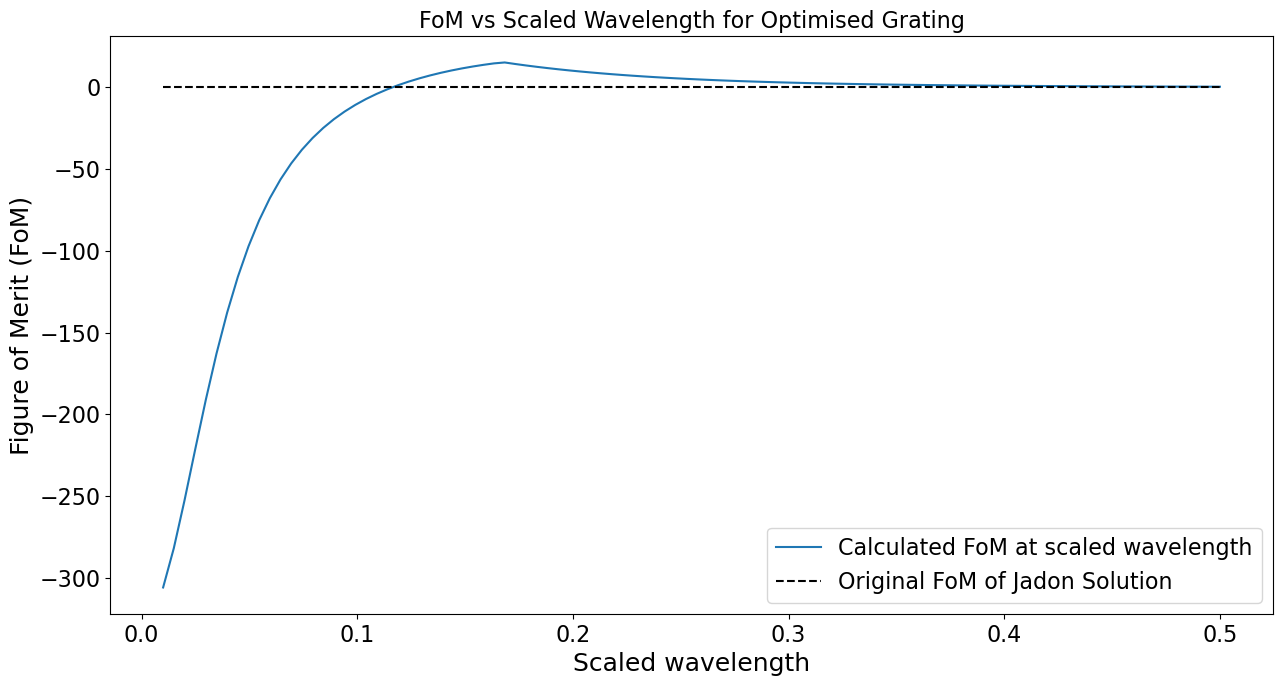

In [10]:
import matplotlib.pyplot as plt
plt.clf()
plt.plot(scales, calc_foms, label='Calculated FoM at scaled wavelength')

plt.plot(scales, np.zeros_like(scales)+actual_fom, 'k--', label='Original FoM of Jadon Solution')
plt.xlabel('Scaled wavelength')
plt.ylabel('Figure of Merit (FoM)')
plt.title('FoM vs Scaled Wavelength for Optimised Grating')
plt.legend()

In [8]:
scaled = 1.05 #scales[np.argmax(calc_foms)]

scaled_opt_params = opt_params.copy()

param_ls = [0, 1, 2, 3, 4, 7, 8]
for p in param_ls:
    scaled_opt_params[p] = scaled * scaled_opt_params[p]
    
scaled_grating = TwoBox(*scaled_opt_params, wavelength=1, angle=0., # wavelength can be set to scaled or 1
                        Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf, # increased nG
                        RCWA_engine=opt_grating.RCWA_engine, 
                        torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

recorded_fom = fom.multifom(scaled_grating, monofom=fom.monofom_asymp,
                            final_speed=final_speed, goal=0.1, return_grad=False)

print_grating_params(scaled_grating)
print(f"FoM at scaled wavelength {1}: {recorded_fom}")

grating_pitch   = 1.6684490594324743
grating_depth   = 0.7155274861003517
box1_width      = 1.2216943030532805
box2_width      = 1.2883488170472646
box_centre_dist = 0.5085346504788729
box1_eps        = 12.249968465054828
box2_eps        = 8.43981679664437
gaussian_width  = 21.0
substrate_depth = 1.9325248299802156
substrate_eps   = 7.724841176163067
FoM at scaled wavelength 1: -115.26061433080287


[1.0498803  1.05010962]


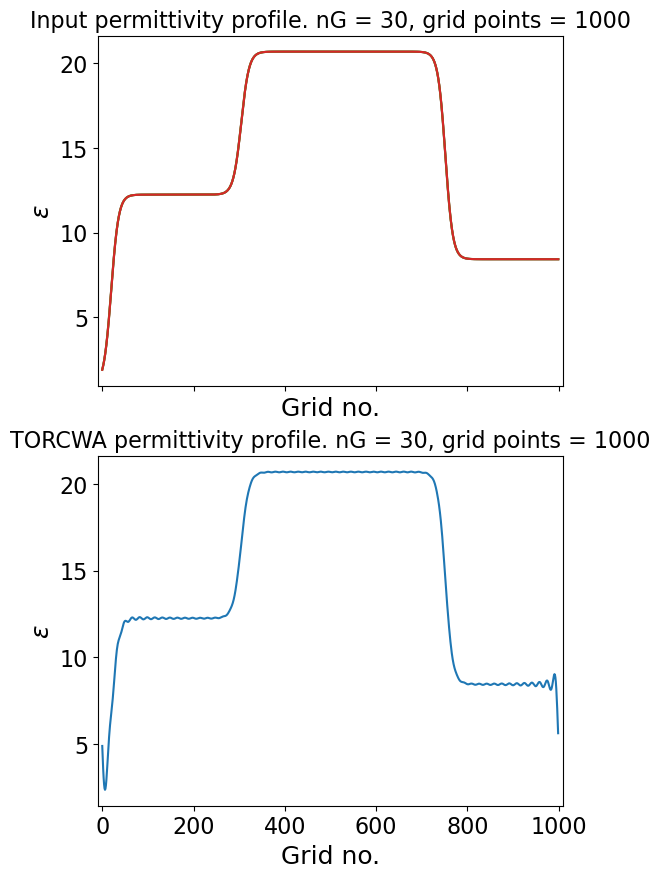

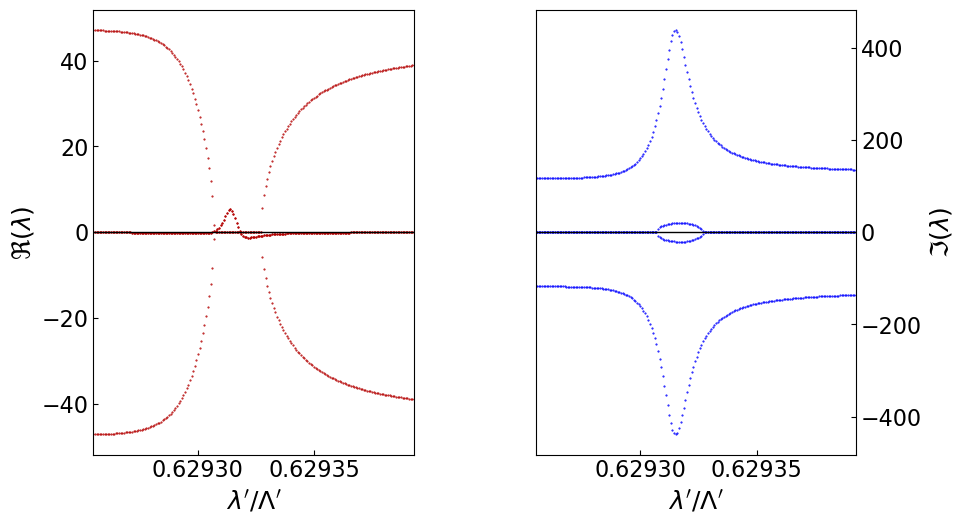

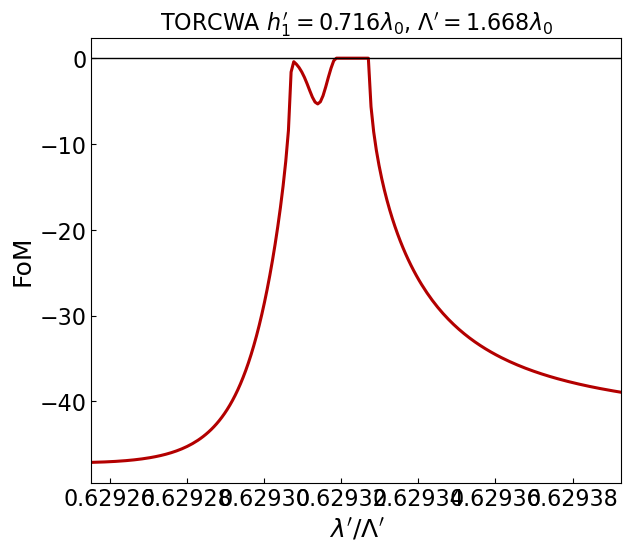

In [9]:
angle = 0.
n_plot = 200

wavelength_range = [0.99999,1.0000004]
bandwidth = wavelength_range[1] - wavelength_range[0]
relative_bandwidth = bandwidth / wavelength_range[0]
wavelength_range = [0.99999 - 10.*relative_bandwidth, 1.0000004 + 10.*relative_bandwidth]


wavelength_range = np.array(wavelength_range) * scaled
print(wavelength_range)

# _, _, p_fig, p_ax = grating.show_permittivity(show_analytic_box=True, show_box_edges=False)
_, _, p_fig, p_ax = scaled_grating.show_permittivity(show_analytic_box=True)
eig_fig, eig_ax = scaled_grating.show_Eigs(wavelength_range, I0, n_plot, False, False, 'o')
spec_fig, spec_ax = scaled_grating.show_FOM_spectrum(angle=angle, wavelength_range=wavelength_range, num_plot_points=n_plot, I=I0)

save_fname = fname_preamble / "scaled" /  f"opt{optimum_number}"
save_fname.mkdir(parents=True, exist_ok=True)
p_fig.savefig(save_fname / f"opt{optimum_number}_permittivity.pdf", bbox_inches = "tight")
eig_fig.savefig(save_fname / f"opt{optimum_number}_eigvals.pdf", bbox_inches = "tight")
spec_fig.savefig(save_fname / f"opt{optimum_number}_F_lam_spectrum.pdf", bbox_inches = "tight")

[0.99988599895999, 1.00010440104001]


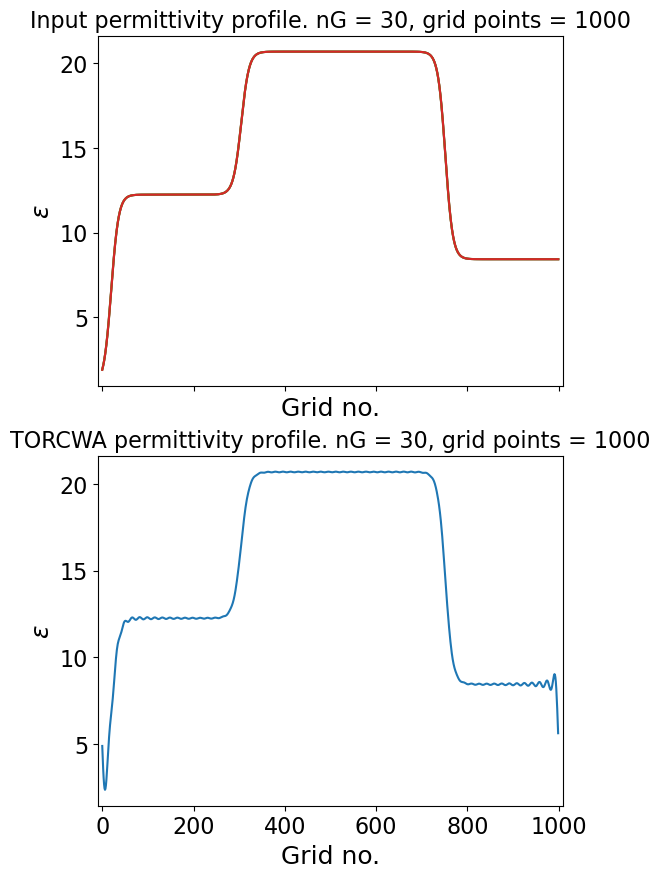

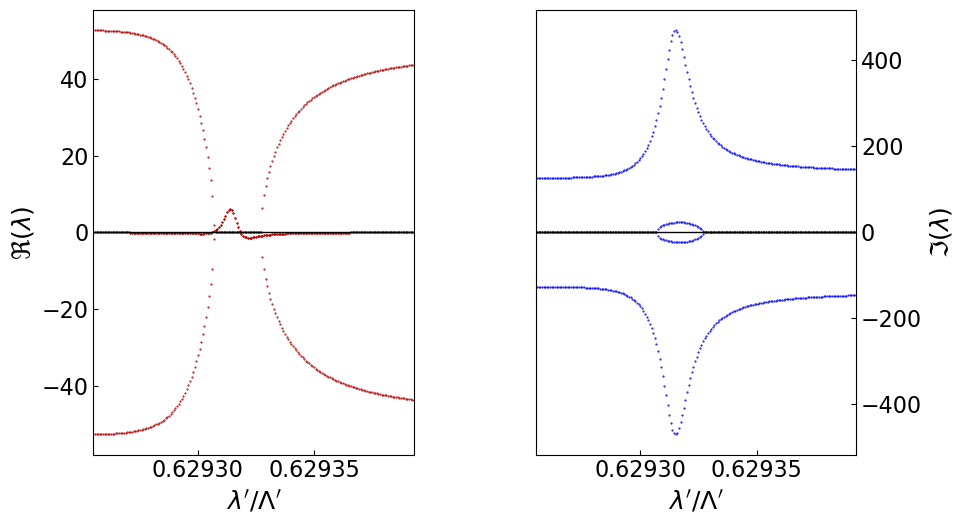

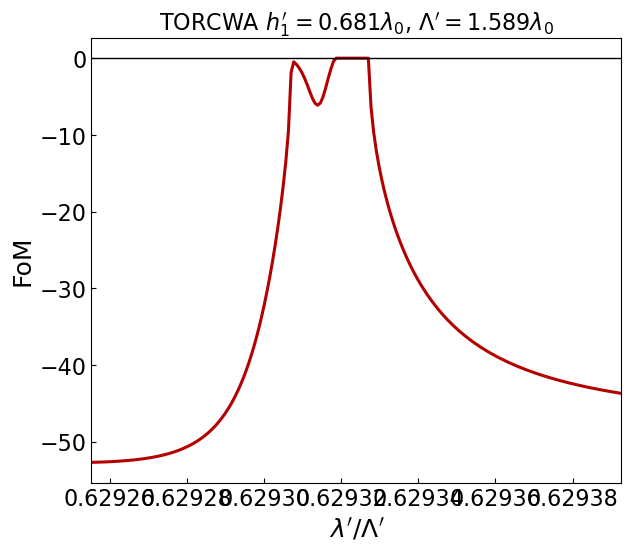

In [10]:
angle = 0.
n_plot = 200

wavelength_range = [0.99999,1.0000004]
bandwidth = wavelength_range[1] - wavelength_range[0]
relative_bandwidth = bandwidth / wavelength_range[0]
wavelength_range = [0.99999 - 10.*relative_bandwidth, 1.0000004 + 10.*relative_bandwidth]
print(wavelength_range)

# _, _, p_fig, p_ax = grating.show_permittivity(show_analytic_box=True, show_box_edges=False)
_, _, p_fig, p_ax = grating.show_permittivity(show_analytic_box=True)
eig_fig, eig_ax = grating.show_Eigs(wavelength_range, I0, n_plot, False, False, 'o')
spec_fig, spec_ax = grating.show_FOM_spectrum(angle=angle, wavelength_range=wavelength_range, num_plot_points=n_plot, I=I0)

save_fname = fname_preamble / "original" /  f"opt{optimum_number}"
save_fname.mkdir(parents=True, exist_ok=True)
p_fig.savefig(save_fname / f"opt{optimum_number}_permittivity.pdf", bbox_inches = "tight")
eig_fig.savefig(save_fname / f"opt{optimum_number}_eigvals.pdf", bbox_inches = "tight")
spec_fig.savefig(save_fname / f"opt{optimum_number}_F_lam_spectrum.pdf", bbox_inches = "tight")

In [5]:
stiffnesses = fom.force_coeff(grating,I0,m,c,grad_method="finite",out="mat",normalise=False) # to get jacobian/matrix

J = grating.npa.concatenate((grating.npa.array([[0,0,1,0],[0,0,0,1]]), stiffnesses))


eigReal, eigImag = fom.Eigs(grating,I0,m,c,grad_method="finite",
                            return_vec = False, normalise=False, use_perturbed=False) # to get eigenvalues

# i think just replace grating with the grating needed (scaled or original)

In [6]:
J

tensor([[ 0.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00],
        [-8.4134e+01,  4.2414e+03, -3.2698e-04, -1.7195e+00],
        [ 9.8901e+02, -6.4979e+04, -2.1675e-04, -1.9519e+00]],
       dtype=torch.float64, grad_fn=<CatBackward0>)

In [14]:
eigReal, eigImag

(tensor([-0.9619, -0.9619, -0.0142, -0.0142], dtype=torch.float64,
        grad_fn=<SelectBackward0>),
 tensor([ 255.0349, -255.0349,    4.4226,   -4.4226], dtype=torch.float64,
        grad_fn=<SelectBackward0>))